In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/kaggle/input/datasets/ismailperacha/nba-tanking-teams-2019-2025/NBA Tanking Dataset - dataset.csv")
df.head()

,season,team,conference,win_pct,wins,losses,league_rank,lottery_seed,actual_pick,pick_jump,had_own_pick,pick_conveyed,pick_team,playoffs_next_year,playoffs_in_2yrs,playoffs_in_3yrs,years_to_playoffs,best_record_next_3yrs,made_playoffs_within_3yrs
0,2018-19,New York Knicks,Eastern,0.207,17,65,30,1,3,-2,1,0,New York Knicks,0,1,0,2.0,0.569,1
1,2018-19,Cleveland Cavaliers,Eastern,0.232,19,63,29,2,5,-3,1,0,Cleveland Cavaliers,0,0,0,4.0,0.537,0
2,2018-19,Phoenix Suns,Western,0.232,19,63,28,3,6,-3,1,0,Minnesota Timberwolves,0,1,1,2.0,0.780,1
3,2018-19,Chicago Bulls,Eastern,0.268,22,60,27,4,7,-3,1,0,Chicago Bulls,0,0,1,3.0,0.561,1
4,2018-19,Atlanta Hawks,Eastern,0.353,29,53,26,5,8,-3,1,0,New Orleans Pelicans,0,1,1,2.0,0.569,1


In [5]:
# Converting NaN columns properly
df['years_to_playoffs'] = pd.to_numeric(df['years_to_playoffs'], errors='coerce')

# Creating helper column
df['made_playoffs_within_3yrs'] = (
    (df['playoffs_next_year'] == 1) |
    (df['playoffs_in_2yrs'] == 1) |
    (df['playoffs_in_3yrs'] == 1)
).astype(int)

# Question 1
**Do worse teams still get significantly better picks?**

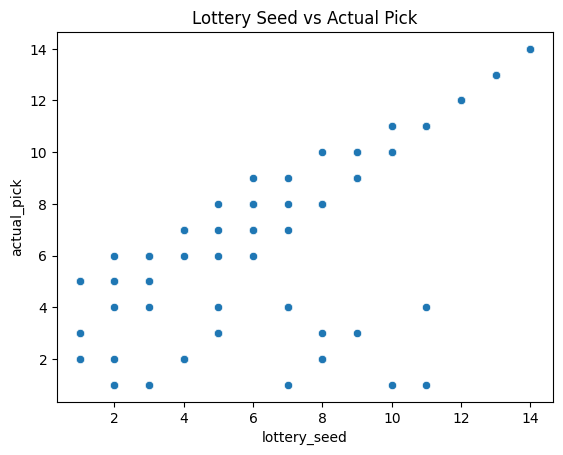

In [6]:
sns.scatterplot(data=df, x='lottery_seed', y='actual_pick')
plt.title("Lottery Seed vs Actual Pick")
plt.show()

In [7]:
df.groupby('lottery_seed')['actual_pick'].mean()

lottery_seed
1      3.571429
2      3.428571
3      4.000000
4      4.714286
5      4.857143
6      7.571429
7      5.285714
8      5.857143
9      8.428571
10     9.000000
11     8.571429
12    12.000000
13    13.000000
14    14.000000
Name: actual_pick, dtype: float64

### Interpretation

The scatterplot shows a general positive relationship between lottery seed and actual draft position, meaning worse teams (lower seeds) tend to receive better picks. However, the spread of points, especially among the bottom seeds, indicates significant variability. Even the worst teams do not consistently receive top picks, suggesting that the post-2019 lottery system has reduced the guarantee of high draft rewards for the lowest-performing teams.

# Question 2
**Are bottom teams still getting better picks than mid-lottery teams?**

In [8]:
def tier(seed):
    if seed <= 3:
        return "Bottom 3"
    elif seed <= 8:
        return "Mid Lottery"
    else:
        return "Fringe Lottery"

df['tier'] = df['lottery_seed'].apply(tier)

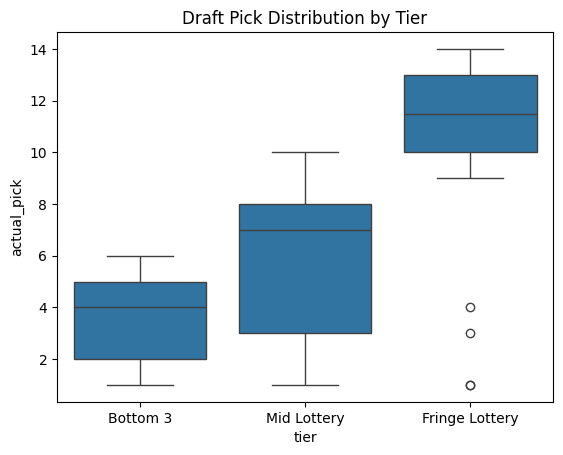

In [9]:
df.groupby('tier')['actual_pick'].mean()
sns.boxplot(data=df, x='tier', y='actual_pick')
plt.title("Draft Pick Distribution by Tier")
plt.show()

### Interpretation

The boxplot highlights clear differences in draft outcomes across tiers. While the bottom 3 teams still tend to receive better picks on average, there is noticeable overlap with mid-lottery teams. This suggests that the advantage of finishing with the worst records is less pronounced than before, as mid-tier lottery teams can still move into favorable draft positions due to the flattened odds structure.

# Question 3
**Do worse teams actually improve faster?**

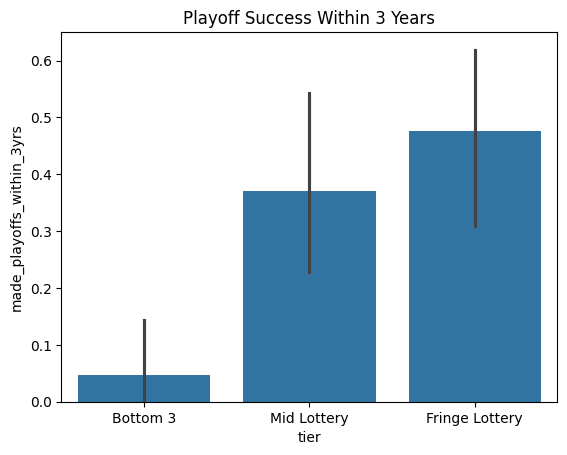

In [11]:
df.groupby('tier')['made_playoffs_within_3yrs'].mean()
sns.barplot(data=df, x='tier', y='made_playoffs_within_3yrs')
plt.title("Playoff Success Within 3 Years")
plt.show()

### Interpretation

The results show that teams in the bottom 3 have the lowest rate of making the playoffs within three years, while mid and fringe lottery teams perform noticeably better. This suggests that extreme tanking does not necessarily lead to faster team improvement. In fact, teams that are slightly more competitive may be better positioned for quicker success, possibly due to stronger existing rosters or more stable development environments.

# Question 4
**Do worse teams reach playoffs faster?**

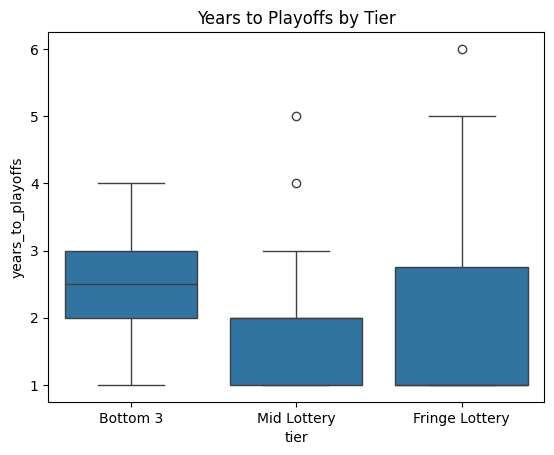

In [12]:
df.groupby('tier')['years_to_playoffs'].mean()
sns.boxplot(data=df, x='tier', y='years_to_playoffs')
plt.title("Years to Playoffs by Tier")
plt.show()

### Interpretation

The results suggest that bottom 3 teams do not reach the playoffs faster than other lottery teams. In fact, mid and fringe lottery teams appear to have shorter times to playoff appearances on average. This indicates that extreme tanking may actually delay a team’s path to contention, possibly due to weaker rosters and longer rebuild timelines.

# Question 5
**Does getting a better pick actually matter?**

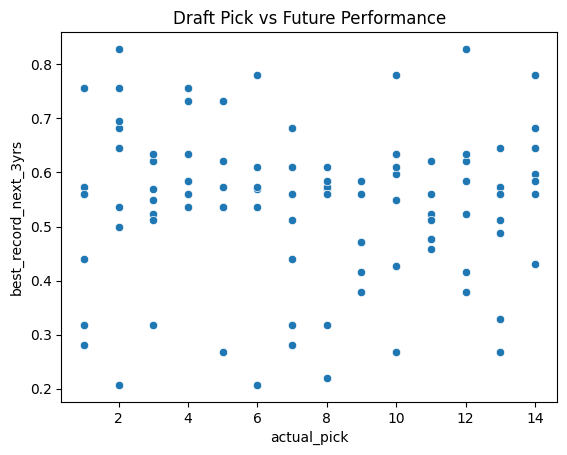

In [15]:
sns.scatterplot(data=df, x='actual_pick', y='best_record_next_3yrs')
plt.title("Draft Pick vs Future Performance")
plt.show()

### Interpretation

The scatterplot shows little to no clear relationship between draft position and future team performance. While some high picks lead to strong outcomes, there is significant variability, and many later picks still result in competitive teams. This suggests that simply obtaining a better draft pick does not guarantee improved performance, and other factors such as player development, roster construction, and organizational stability play a major role.

# Question 6
**Do teams that lose their pick recover slower?**

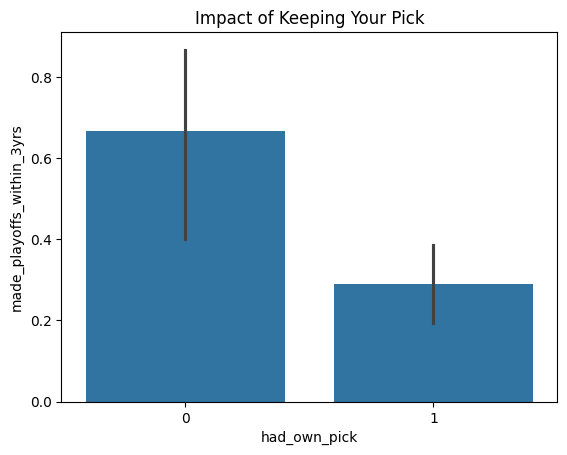

In [16]:
df.groupby('had_own_pick')['made_playoffs_within_3yrs'].mean()
sns.barplot(data=df, x='had_own_pick', y='made_playoffs_within_3yrs')
plt.title("Impact of Keeping Your Pick")
plt.show()

### Interpretation

The data shows that teams which do not retain their own pick tend to have higher playoff success within three years compared to those that keep their pick. This may seem counterintuitive, but it likely reflects that teams losing their picks are often already more competitive or have traded picks to accelerate improvement. In contrast, teams keeping their picks are more likely in earlier stages of a rebuild, which delays short-term success.

# THE MAIN QUESTION
**How long does it take bad teams to recover?**

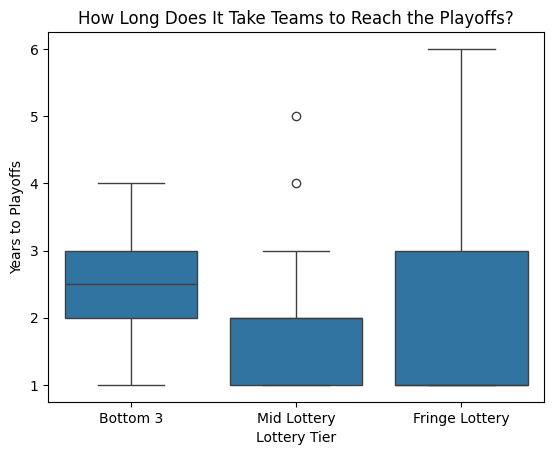

tier
Bottom 3          2.625000
Fringe Lottery    1.962963
Mid Lottery       1.961538
Name: years_to_playoffs, dtype: float64

In [24]:
sns.boxplot(
    data=df_final,
    x='tier',
    y='years_to_playoffs',
    order=['Bottom 3', 'Mid Lottery', 'Fringe Lottery']
)

plt.title("How Long Does It Take Teams to Reach the Playoffs?")
plt.xlabel("Lottery Tier")
plt.ylabel("Years to Playoffs")

plt.show()

df_final.groupby('tier')['years_to_playoffs'].mean()

## Final Takeaway

The data shows that bottom-tier teams are not stuck at the bottom indefinitely, as they typically return to the playoffs within a few years. However, they do take longer to recover compared to other lottery teams.

Teams in the mid and fringe lottery tend to reach the playoffs faster, likely because they already have stronger foundations and require less rebuilding.

This suggests that while the current system does not trap bad teams, extreme tanking also does not accelerate recovery. Instead, it may actually slow down the path back to competitiveness.